# Phase 1: propagation-tree visualization

This notebook visualizes the propagation-tree artifacts generated by `explore_data.ipynb`.

**Primary dataset: WICO.** All tree/graph visualizations (Sections 4–6) target WICO cascades.
Twitter15/16 visualizations are included separately in Section 7 and do not overlap with WICO.

Work carried out here:

1. Load the configured evaluation directory and Phase 1 catalog files.
2. Reconstruct selected WICO propagation graphs from their saved graph paths.
3. Plot 3 representative false and 3 true WICO cascades with root nodes highlighted.
4. Plot depth profiles showing how each WICO cascade expands over time or levels.
5. Cascade timelines and BiGCN dual view — all using WICO data.
6. Aggregate WICO true vs false comparisons.
7. Twitter15/16 visualizations (separate, reference only).
8. Dataset-level comparison across all datasets.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import re
import math
import random
import sys
import importlib.util

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def _load_project_config():
    """Load the central configuration object from the project root.

    Preferred filename is config.py. The fallback supports the uploaded
    config(1).py name used in this chat, so the notebook is runnable here too.
    """
    search_dirs = [Path.cwd(), Path.cwd().parent, Path('/mnt/data')]
    names = ['config.py', 'config(1).py']
    for base in search_dirs:
        for name in names:
            path = base / name
            if path.exists():
                if str(base) not in sys.path:
                    sys.path.insert(0, str(base))
                if name == 'config.py':
                    from config import cfg, ROOT as CONFIG_ROOT
                    return cfg, CONFIG_ROOT, path
                spec = importlib.util.spec_from_file_location('project_config', path)
                module = importlib.util.module_from_spec(spec)
                sys.modules[spec.name] = module
                spec.loader.exec_module(module)
                return module.cfg, module.ROOT, path
    raise FileNotFoundError(
        'Could not find config.py. Place config.py in the project root, '
        'start Jupyter from the project root, or keep config(1).py next to this notebook.'
    )

cfg, CONFIG_ROOT, CONFIG_PATH = _load_project_config()

RANDOM_SEED = cfg.seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(CONFIG_ROOT).resolve()
EVAL_DIR     = cfg.paths.evaluation
SUMMARY_PATH = EVAL_DIR / 'propagation_tree_summary.csv'
SAMPLES_PATH = EVAL_DIR / 'sample_tree_ids.csv'
FIG_DIR      = EVAL_DIR / 'tree_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Config loaded from: {CONFIG_PATH}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Evaluation directory: {EVAL_DIR}')
print(f'Figure directory: {FIG_DIR}')


Config loaded from: /home/krmsh1n5/Desktop/UFAZ/infoshield/config.py
Project root: /home/krmsh1n5/Desktop/UFAZ/infoshield
Evaluation directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation
Figure directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures


## 1. Load the Phase 1 catalog from the configured evaluation directory

Run `explore_data.ipynb` first. It creates the summary and sample CSV files used here under `cfg.paths.evaluation`.


In [2]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing {SUMMARY_PATH}. Run explore_data.ipynb first.')

_STR_COLS = {'tweet_id': str, 'content_id': str, 'root_user': str, 'label': str,
             'raw_label': str, 'text': str, 'graph_path': str}
_REQUIRED_COLS = ['dataset','tweet_id','label','cascade_size','max_depth','max_width','graph_path']
_SUMMARY_COLS = [
    'dataset','tweet_id','content_id','root_user','label','raw_label',
    'graph_path','text','num_nodes','num_edges','cascade_size','max_depth',
    'max_width','branching_ratio','num_roots','is_arborescence','temporal_span'
]

def _read_catalog_csv(path, columns):
    try:
        df = pd.read_csv(path, dtype=_STR_COLS)
    except pd.errors.EmptyDataError:
        df = pd.DataFrame(columns=columns)
    for col in columns:
        if col not in df.columns:
            df[col] = pd.Series(dtype='object')
    return df

tree_summary = _read_catalog_csv(SUMMARY_PATH, _SUMMARY_COLS)
tree_summary['label'] = tree_summary['label'].astype(str).str.lower().str.strip()
if 'root_user' not in tree_summary.columns:
    tree_summary['root_user'] = None

if SAMPLES_PATH.exists():
    sample_trees = _read_catalog_csv(SAMPLES_PATH, _SUMMARY_COLS)
    sample_trees['label'] = sample_trees['label'].astype(str).str.lower().str.strip()
    if 'root_user' not in sample_trees.columns:
        sample_trees['root_user'] = None
else:
    sample_trees = tree_summary.sort_values(
        ['cascade_size','max_depth'], ascending=False).head(6)

print('Summary rows:', len(tree_summary))
print('Sample rows:', len(sample_trees))
print('Label values in sample_trees:', sample_trees['label'].unique().tolist())
if sample_trees.empty:
    print('No sample trees found. Run explore_data.ipynb after placing datasets at the configured paths.')
    display(sample_trees.reindex(columns=_REQUIRED_COLS))
else:
    display(sample_trees[_REQUIRED_COLS])


Summary rows: 4765
Sample rows: 6
Label values in sample_trees: ['true', 'false']


,dataset,tweet_id,label,cascade_size,max_depth,max_width,graph_path
0,WICO,689,true,101,3,62,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
1,WICO,2028,true,101,1,2,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
2,WICO,950,true,101,0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
3,WICO,350,false,100,2,10,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
4,WICO,435,false,100,0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
5,WICO,185,false,99,6,6,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...


## 2. Tree parsing helpers

These are repeated so this notebook can reload graph files directly from the paths saved by the exploration notebook.

In [3]:
def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s[:-2]
    return s


def parse_edge_line(line):
    """Parse one edge line from a Twitter15/16 tree file.

    Returns (parent_uid, child_uid, delay_float) or None.
    parent_uid may be 'ROOT' for the sentinel line.
    """
    raw = line.strip()
    if not raw or '->' not in raw:
        return None
    halves = raw.split('->', 1)
    if len(halves) != 2:
        return None

    def extract_fields(s):
        return re.findall(r"'([^']*?)'", s)

    parent_fields = extract_fields(halves[0])
    child_fields  = extract_fields(halves[1])
    if not parent_fields or not child_fields:
        return None
    parent_uid = normalize_id(parent_fields[0])
    child_uid  = normalize_id(child_fields[0])
    delay = None
    if len(child_fields) >= 3:
        try:
            delay = float(child_fields[2])
        except ValueError:
            pass
    return parent_uid, child_uid, delay


def graph_from_edges(edge_rows, root_sentinel=None):
    """Build (DiGraph, root_user_id) from (parent_uid, child_uid, delay) tuples.

    ROOT sentinel identifies the source user as root_user_id.
    No phantom ROOT node is added; all nodes stay in user-ID namespace.

    root_sentinel defaults to cfg.twitter15.root_sentinel ('ROOT').
    Pass cfg.twitter16.root_sentinel when loading Twitter16 trees.
    """
    if root_sentinel is None:
        root_sentinel = cfg.twitter15.root_sentinel  # both datasets use 'ROOT'
    G = nx.DiGraph()
    root_user_id = None
    for parent, child, delay in edge_rows:
        parent = normalize_id(parent)
        child  = normalize_id(child)
        if parent is None or child is None:
            continue
        if parent.upper() == root_sentinel.upper():
            if root_user_id is None:
                root_user_id = child
            G.add_node(child)
        else:
            G.add_edge(parent, child)
            if delay is not None:
                G.nodes[child]['delay'] = delay
    return G, root_user_id


def _wico_find_root(G, nodes_df):
    """Most-followed user in nodes.csv that appears in G, else highest in-degree."""
    if not nodes_df.empty and 'id' in nodes_df.columns:
        if 'followers' in nodes_df.columns:
            cands = nodes_df[nodes_df['id'].map(normalize_id).isin(G.nodes)].copy()
            if not cands.empty:
                try:
                    cands['followers'] = pd.to_numeric(cands['followers'], errors='coerce')
                    best = cands.loc[cands['followers'].idxmax(), 'id']
                    bid  = normalize_id(best)
                    if bid in G:
                        return bid
                except Exception:
                    pass
        for _, nr in nodes_df.iterrows():
            nid = normalize_id(nr.get('id'))
            if nid and nid in G:
                return nid
    if G.number_of_nodes() > 0:
        return max(G.nodes, key=lambda n: G.in_degree(n))
    return None


def load_graph_for_row(row):
    """Reconstruct a DiGraph from a catalog row.

    graph_path may be:
      - A .txt file : Twitter15/16 tree file
      - A directory : WICO Graph per-tweet folder (edges.txt + nodes.csv)

    Returns (G, root_user_id).
    """
    graph_path = row.get('graph_path')
    if not graph_path or pd.isna(graph_path):
        raise ValueError('No graph_path in row')
    path     = Path(str(graph_path))
    # root_user column is present in CSVs generated by the fixed explore_data
    stored_root = normalize_id(row.get('root_user'))

    if not path.exists():
        raise FileNotFoundError(path)

    # ── WICO Graph: graph_path is a directory ────────────────────────────
    if path.is_dir():
        edges_path = path / cfg.wico.graph_edges_file
        G = nx.DiGraph()
        if edges_path.exists():
            for line in edges_path.read_text(errors='ignore').splitlines():
                parts = line.strip().split()
                if len(parts) == 2:
                    src, dst = normalize_id(parts[0]), normalize_id(parts[1])
                    if src and dst:
                        G.add_edge(src, dst)
        nodes_path = path / cfg.wico.graph_nodes_file
        nodes_df   = pd.DataFrame()
        if nodes_path.exists():
            nodes_df = pd.read_csv(nodes_path, dtype=str)
            nodes_df.columns = [c.strip().lower() for c in nodes_df.columns]
            # Use cfg.wico.graph_nodes_columns as source of truth for feature names
            _feat_cols = [c for c in cfg.wico.graph_nodes_columns if c != 'id']
            for _, nr in nodes_df.iterrows():
                nid = normalize_id(nr.get('id'))
                if nid:
                    G.add_node(nid)
                    for feat in _feat_cols:
                        try:
                            G.nodes[nid][feat] = int(float(nr[feat]))
                        except (ValueError, KeyError, TypeError):
                            pass
        # FIX: prefer stored root (from explore_data CSV); fall back to heuristic
        root_user_id = (stored_root if stored_root and stored_root in G
                        else _wico_find_root(G, nodes_df))
        return G, root_user_id

    # ── Twitter15/16: graph_path is a .txt tree file ─────────────────────
    # Use cfg.twitter15.root_sentinel; Twitter16 uses the same value ('ROOT')
    edge_rows = []
    for line in path.read_text(errors='ignore').splitlines():
        parsed = parse_edge_line(line)
        if parsed:
            edge_rows.append(parsed)
    G, root_user_id = graph_from_edges(edge_rows, root_sentinel=cfg.twitter15.root_sentinel)
    # Prefer the stored root_user from the CSV if available and present in G
    if stored_root and stored_root in G:
        root_user_id = stored_root
    return G, root_user_id


def make_synthetic_tree(label, n_nodes=40, seed=0):
    """Generate a synthetic propagation tree for demo/fallback use.

    False trees are wide and shallow (burst spreading).
    True trees are narrow and deep (chain verification).
    Temporal delays are attached to nodes to enable timeline plots.
    """
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    root = 'u0'
    G.add_node(root)
    G.nodes[root]['delay'] = 0.0
    queue = [root]
    uid   = 1
    if label == 'false':
        # Wide bursts: each node fans out to 3-6 children quickly
        while queue and uid < n_nodes:
            parent = queue.pop(0)
            fan    = int(rng.integers(3, 7))
            parent_delay = G.nodes[parent].get('delay', 0)
            for _ in range(fan):
                if uid >= n_nodes:
                    break
                child = f'u{uid}'
                delay = parent_delay + float(rng.exponential(2))
                G.add_edge(parent, child)
                G.nodes[child]['delay'] = delay
                queue.append(child)
                uid += 1
    else:
        # Deep chains: each node has 1-2 children, grows slowly
        while queue and uid < n_nodes:
            parent = queue.pop(0)
            fan    = int(rng.integers(1, 3))
            parent_delay = G.nodes[parent].get('delay', 0)
            for _ in range(fan):
                if uid >= n_nodes:
                    break
                child = f'u{uid}'
                delay = parent_delay + float(rng.exponential(8))
                G.add_edge(parent, child)
                G.nodes[child]['delay'] = delay
                queue.append(child)
                uid += 1
    return G, root

print('Helpers defined.')


Helpers defined.


## 3. Layout and plotting helpers

The plots highlight the root node and show the outward reshare structure. For very large cascades, only the first few hundred nodes are drawn to keep the visualization readable.

In [4]:
def find_root(G, preferred=None):
    preferred = normalize_id(preferred)
    if preferred and preferred in G:
        return preferred
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    return roots[0] if roots else (next(iter(G.nodes)) if G.number_of_nodes() else None)


def depth_subgraph(G, root, max_nodes=250):
    if root is None or root not in G:
        return G.copy(), {}
    depths = nx.single_source_shortest_path_length(G, root)
    nodes  = sorted(depths, key=lambda n: (depths[n], str(n)))[:max_nodes]
    H      = G.subgraph(nodes).copy()
    return H, {n: depths[n] for n in H.nodes}


def hierarchy_positions(G, root=None):
    root = find_root(G, root)
    if root is None:
        return {}
    depths   = nx.single_source_shortest_path_length(G, root)
    by_depth = defaultdict(list)
    for n, d in depths.items():
        by_depth[d].append(n)
    pos = {}
    for d, nodes_at_d in by_depth.items():
        nodes_at_d = sorted(nodes_at_d, key=str)
        width = max(1, len(nodes_at_d) - 1)
        for i, n in enumerate(nodes_at_d):
            pos[n] = (i / width - 0.5 if width else 0, -d)
    for i, n in enumerate(n for n in G.nodes if n not in pos):
        pos[n] = (0.75 + (i % 10) * 0.06, -(i // 10))
    return pos


def draw_tree_on_ax(ax, G, root=None, color='#7F77DD', max_nodes=250, title=''):
    """Draw a propagation tree on an existing Axes object."""
    H, depths = depth_subgraph(G, root, max_nodes=max_nodes)
    pos = hierarchy_positions(H, root)
    if not pos:
        ax.text(0.5, 0.5, '(empty graph)', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='gray')
        ax.set_visible(True)
        if title:
            ax.set_title(title, fontsize=8)
        ax.axis('off')
        return H, depths, pos

    out_deg  = dict(H.out_degree())
    max_deg  = max(out_deg.values()) if out_deg else 1
    sizes    = [120 + 500 * (out_deg.get(n, 0) / max(max_deg, 1)) for n in H.nodes()]
    node_colors = [color if n != root else '#222222' for n in H.nodes()]

    nx.draw_networkx_edges(H, pos, ax=ax, edge_color='#cccccc',
                           arrows=True, arrowsize=8, width=0.6, alpha=0.7)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
                           node_size=sizes, alpha=0.88)
    if root and root in pos:
        ax.scatter(*pos[root], s=300, facecolors='none',
                   edgecolors='black', linewidths=2, zorder=5)
    if title:
        ax.set_title(title, fontsize=8)
    ax.axis('off')
    return H, depths, pos


def plot_depth_profile(G, title, root=None):
    root = find_root(G, root)
    if root is None:
        return
    depths = nx.single_source_shortest_path_length(G, root)
    counts = Counter(depths.values())
    xs, ys = zip(*sorted(counts.items())) if counts else ([], [])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(xs, ys, color='#7F77DD', edgecolor='white')
    ax.set_xlabel('Depth from root')
    ax.set_ylabel('Nodes at depth')
    ax.set_title(title, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    safe = re.sub(r'[^A-Za-z0-9_.\-]+', '_', title)[:100]
    out  = FIG_DIR / f'depth_{safe}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)

print('Layout helpers defined.')


Layout helpers defined.


## 4. Visualize WICO cascades — 3 false and 3 true side by side

Trees are selected from **WICO** — 3 largest false-content cascades and
3 largest true-content cascades — so the structural contrast is clear.
Falls back to synthetic demo trees only if WICO data is absent.

> **Note:** Twitter15/16 visualizations are in Section 7 below, kept completely separate.

Loading WICO cascades from sample_trees...
Loaded 6 WICO cascades (3 false, 3 true).

Individual WICO graph plots:


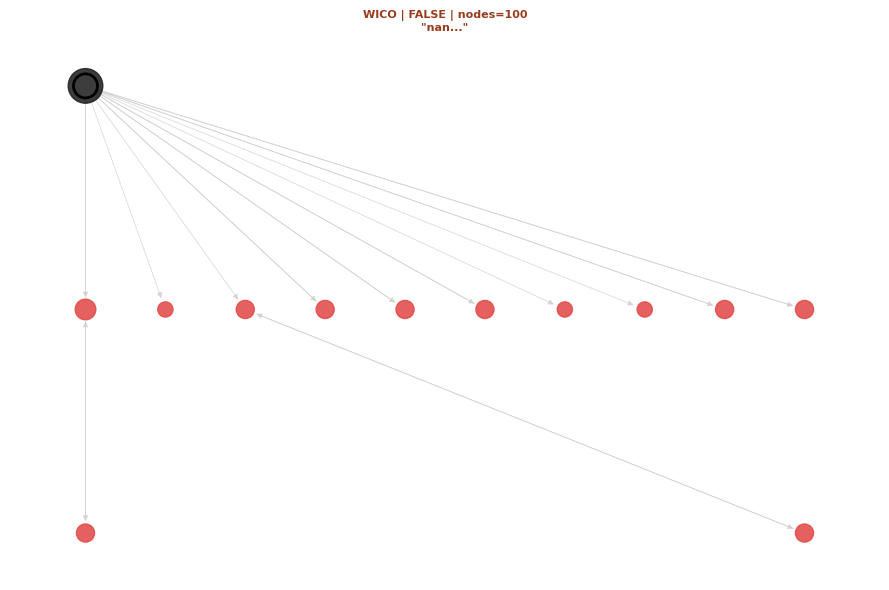

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/graph_WICO_false_350.png


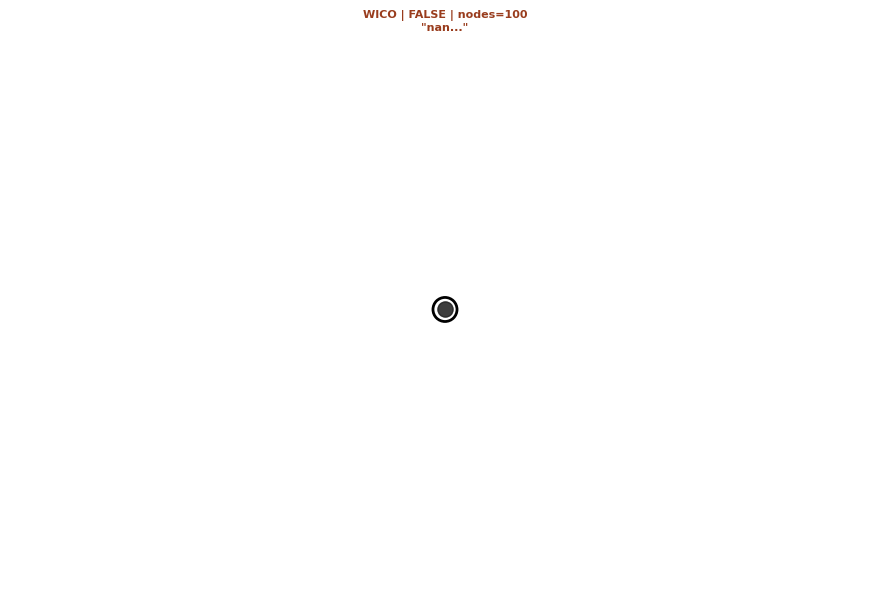

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/graph_WICO_false_435.png


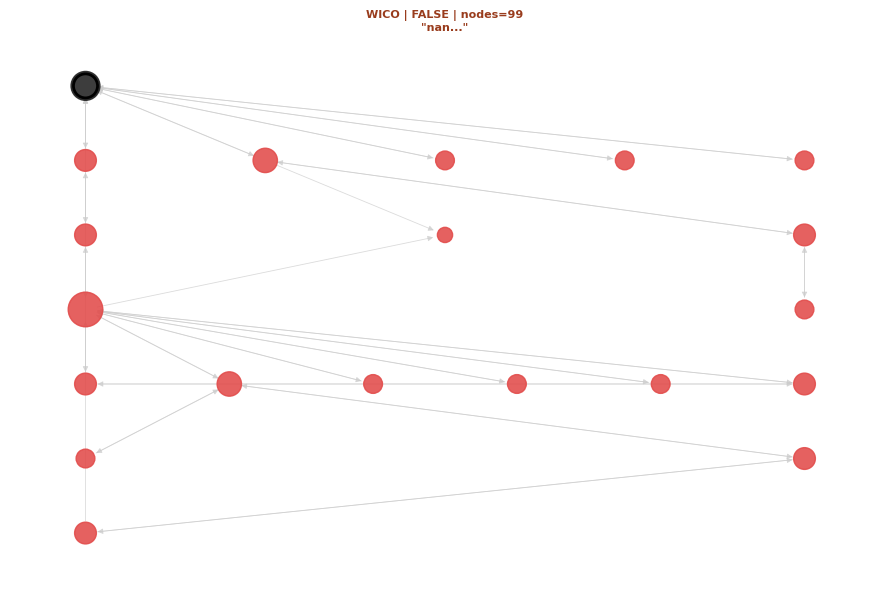

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/graph_WICO_false_185.png


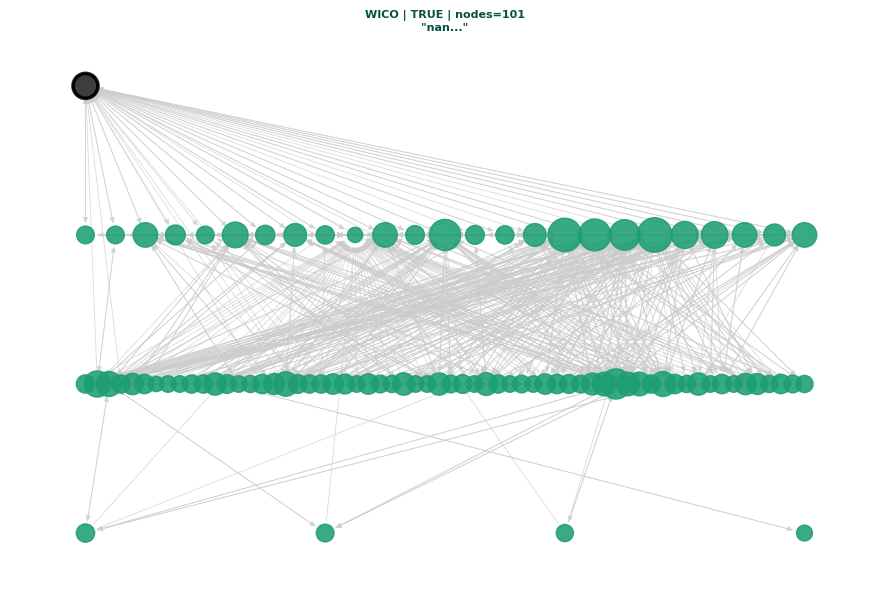

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/graph_WICO_true_689.png


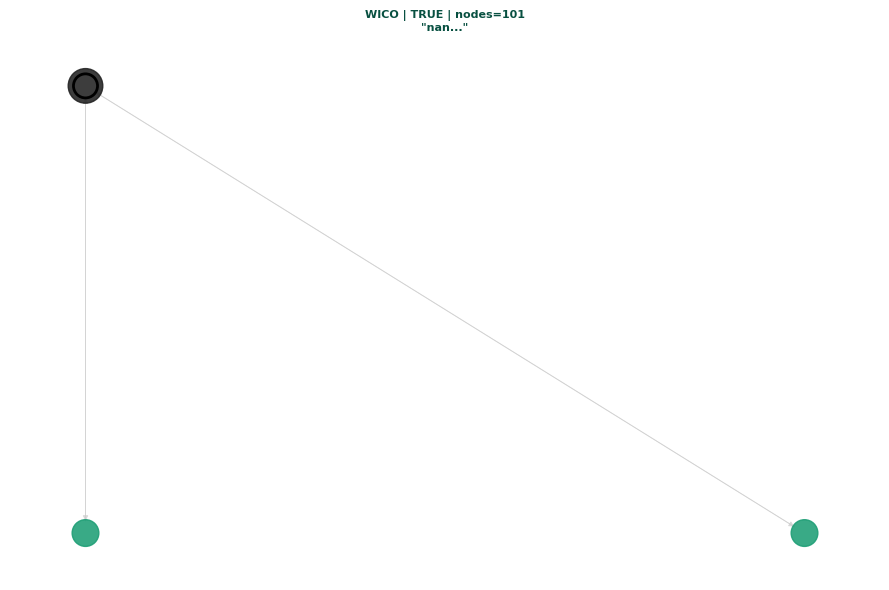

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/graph_WICO_true_2028.png


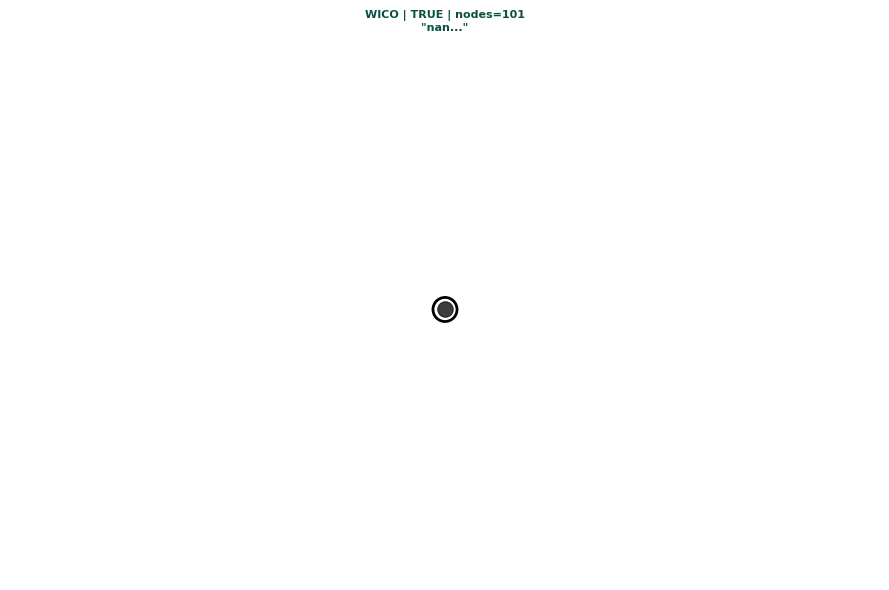

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/graph_WICO_true_950.png


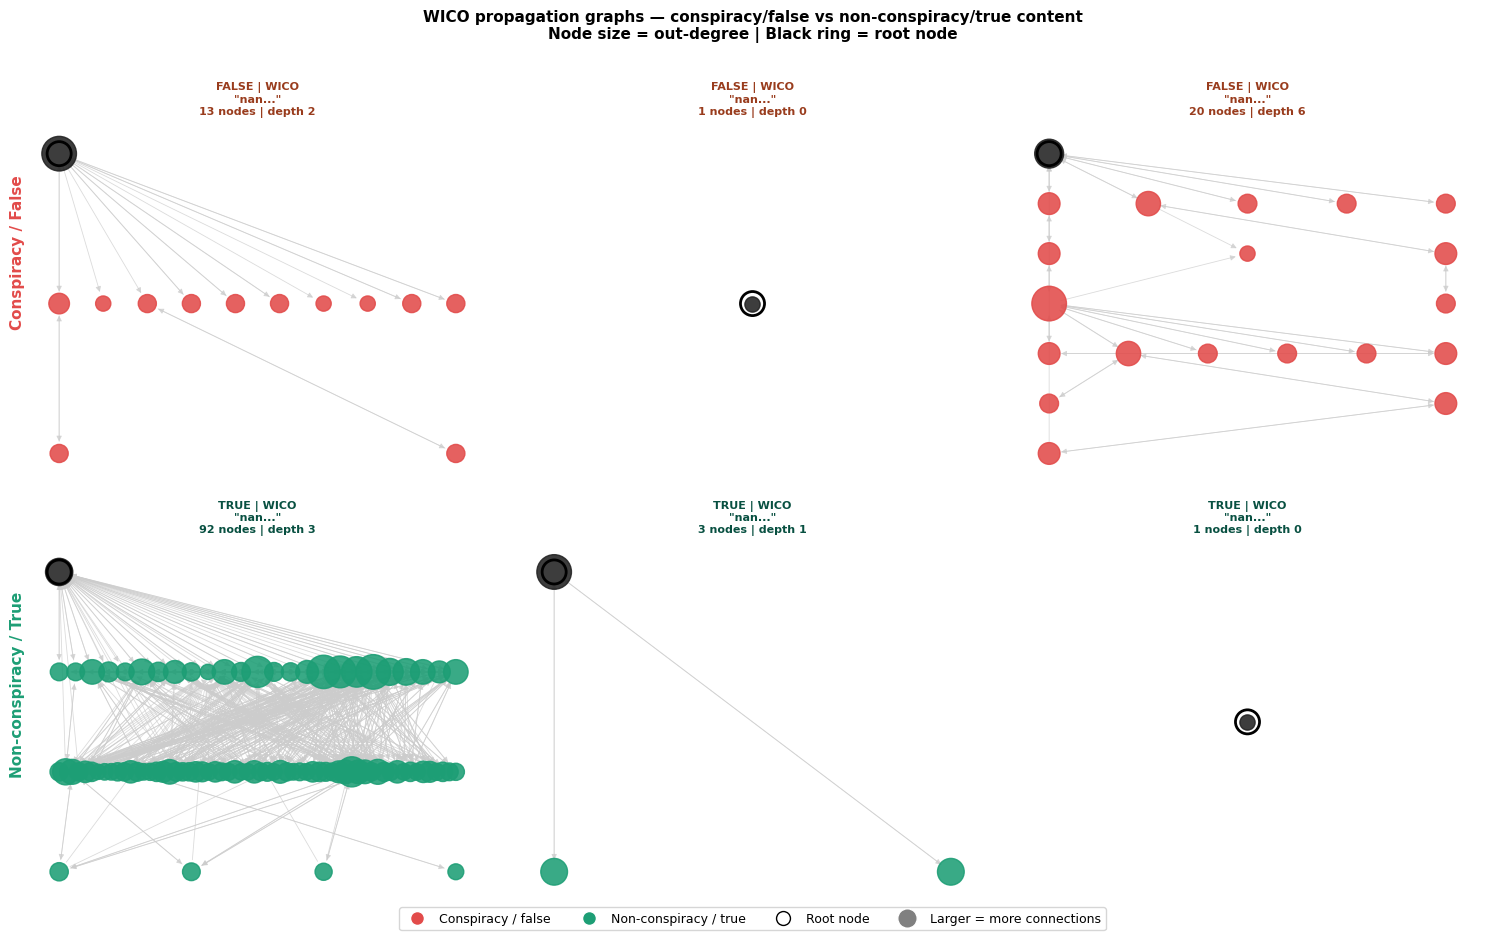


Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/wico_true_vs_false_graph_comparison.png


In [5]:
# ── Step 1: load 3 false + 3 true WICO cascades ─────────────────────────
# Strictly filters to WICO dataset. Falls back to synthetic only if absent.
loaded_graphs = []   # list of (row_dict, G, root_user_id)

wico_sample = (sample_trees[sample_trees['dataset'].eq('WICO')]
               if not sample_trees.empty and 'dataset' in sample_trees.columns
               else pd.DataFrame())

data_available = (
    not wico_sample.empty
    and 'graph_path' in wico_sample.columns
    and wico_sample['graph_path'].notna().any()
)

if data_available:
    print('Loading WICO cascades from sample_trees...')
    for target_label in ['false', 'true']:
        candidates = wico_sample[
            wico_sample['label'].eq(target_label) &
            wico_sample['graph_path'].notna()
        ].sort_values('cascade_size', ascending=False)
        count = 0
        for _, row in candidates.iterrows():
            if count >= 3:
                break
            try:
                G, root_user_id = load_graph_for_row(row)
                loaded_graphs.append((row.to_dict(), G, root_user_id))
                count += 1
            except Exception as e:
                print(f'  Skipped {row.get("content_id", row.get("tweet_id"))}: {e}')
else:
    print('No WICO data found in sample_trees. Using synthetic demo trees.')
    print('(Run explore_data.ipynb with WICO datasets present to get real-data plots.)')
    for label, seeds in [('false', [0, 1, 2]), ('true', [10, 11, 12])]:
        for seed in seeds:
            G, root_user_id = make_synthetic_tree(label, n_nodes=40 + seed * 5, seed=seed)
            row = {
                'dataset': 'WICO-Synthetic', 'tweet_id': f'demo_{label}_{seed}',
                'content_id': f'demo_{label}_{seed}', 'label': label,
                'text': f'[synthetic WICO {label} demo tree #{seed}]',
                'graph_path': None, 'root_user': root_user_id,
                'cascade_size': G.number_of_nodes(),
            }
            loaded_graphs.append((row, G, root_user_id))

n_false = sum(1 for r, _, _ in loaded_graphs if r['label'] == 'false')
n_true  = sum(1 for r, _, _ in loaded_graphs if r['label'] == 'true')
print(f'Loaded {len(loaded_graphs)} WICO cascades ({n_false} false, {n_true} true).')

# ── Step 2: individual tree plots (WICO) ─────────────────────────────────
print('\nIndividual WICO graph plots:')
visualized_graphs = []
for row, G, root_user_id in loaded_graphs:
    label  = row.get('label', 'unknown')
    color  = '#E24B4A' if label == 'false' else ('#1D9E75' if label == 'true' else '#7F77DD')
    root   = find_root(G, root_user_id)
    fig, ax = plt.subplots(figsize=(9, 6))
    H, depths, pos = draw_tree_on_ax(ax, G, root=root, color=color, max_nodes=250)
    short = str(row.get('text', ''))[:60]
    ds    = row.get('dataset', 'WICO')
    cid   = row.get('content_id', row.get('tweet_id', ''))
    ax.set_title(
        f"{ds} | {label.upper()} | nodes={G.number_of_nodes()}\n\"{short}...\"",
        fontsize=8, fontweight='bold',
        color='#993C1D' if label == 'false' else '#085041'
    )
    plt.tight_layout()
    safe_id = re.sub(r'[^A-Za-z0-9_.\-]+', '_', str(cid))
    out = FIG_DIR / f"graph_{ds}_{label}_{safe_id}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print('  Saved:', out)
    visualized_graphs.append((row, G, root_user_id))

# ── Step 3: side-by-side comparison grid (WICO, 2 rows x 3 cols) ─────────
false_items = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'false'][:3]
true_items  = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'true'][:3]
n_cols      = max(len(false_items), len(true_items), 1)

if false_items or true_items:
    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 9), squeeze=False)
    COLOR     = {'false': '#E24B4A', 'true': '#1D9E75'}
    ROW_LABEL = {'false': 'Conspiracy / False', 'true': 'Non-conspiracy / True'}

    for row_idx, (label, items) in enumerate([('false', false_items), ('true', true_items)]):
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(items):
                ax.set_visible(False)
                continue
            row, G, rid = items[col_idx]
            root = find_root(G, rid)
            H, depths, pos = draw_tree_on_ax(ax, G, root=root,
                                             color=COLOR[label], max_nodes=250)
            short = str(row.get('text', ''))[:50]
            ax.set_title(
                f'{label.upper()} | {row.get("dataset","WICO")}\n\"{short}...\"\n'
                f'{H.number_of_nodes()} nodes | depth {max(depths.values()) if depths else 0}',
                fontsize=8, fontweight='bold',
                color='#993C1D' if label == 'false' else '#085041'
            )
        fig.text(0.005, 0.74 if label == 'false' else 0.26,
                 ROW_LABEL[label], fontsize=11, fontweight='bold',
                 color=COLOR[label], rotation=90, va='center')

    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=10, label='Conspiracy / false'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D9E75', markersize=10, label='Non-conspiracy / true'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=10, label='Root node'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=14, label='Larger = more connections'),
    ], loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(
        'WICO propagation graphs — conspiracy/false vs non-conspiracy/true content\n'
        'Node size = out-degree | Black ring = root node',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    out = FIG_DIR / 'wico_true_vs_false_graph_comparison.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved:', out)


## 5. Depth profiles for WICO cascades

Depth profiles make shallow-broad versus deep-chain propagation patterns easier to compare.
These plots are generated from the same WICO cascades visualized above.

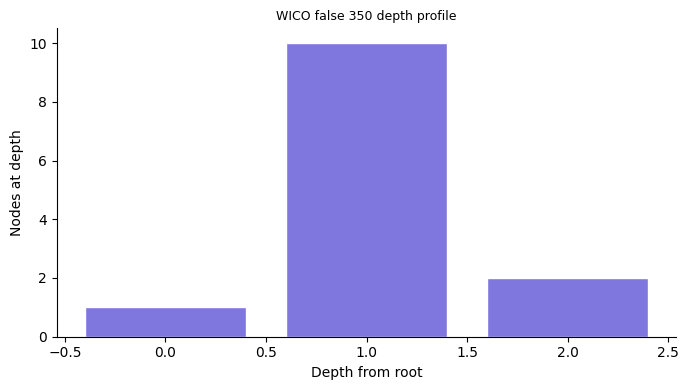

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_WICO_false_350_depth_profile.png


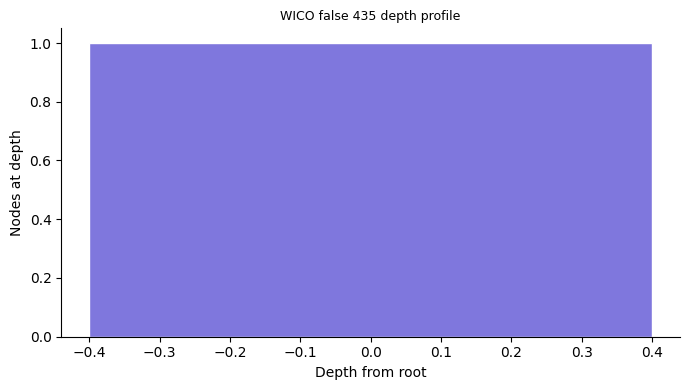

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_WICO_false_435_depth_profile.png


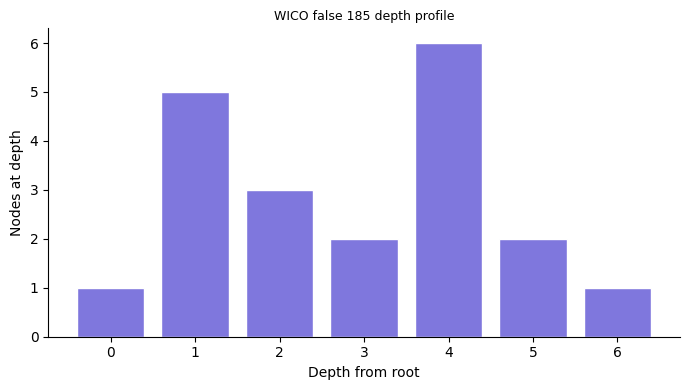

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_WICO_false_185_depth_profile.png


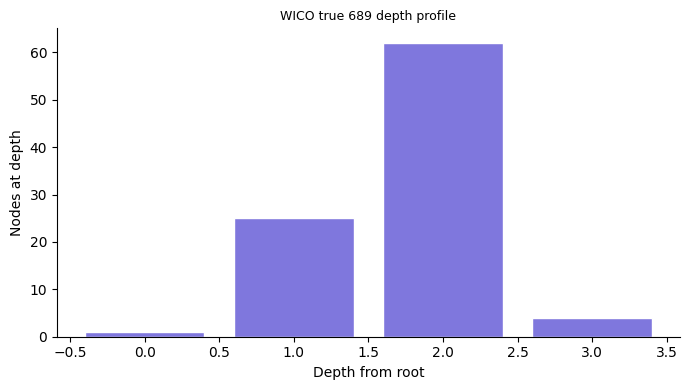

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_WICO_true_689_depth_profile.png


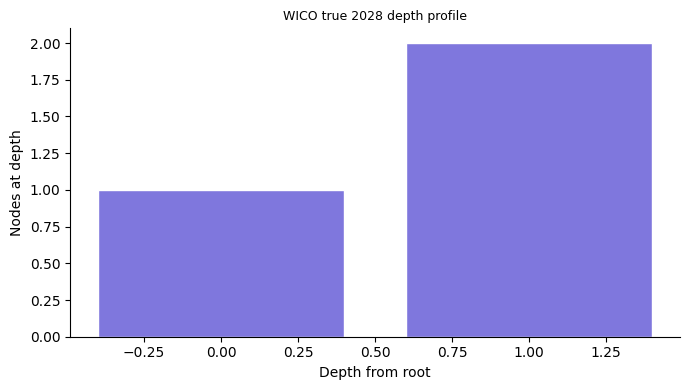

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_WICO_true_2028_depth_profile.png


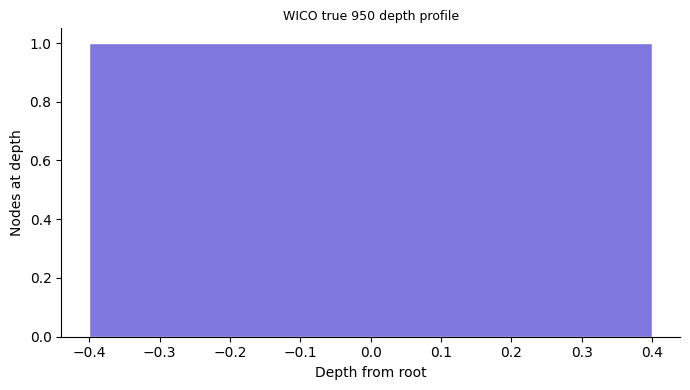

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_WICO_true_950_depth_profile.png


In [6]:
for row, G, rid in visualized_graphs:
    root  = find_root(G, rid)
    title = f"{row['dataset']} {row.get('label','unknown')} {row.get('tweet_id')} depth profile"
    plot_depth_profile(G, title, root=root)

## 5b. WICO cascade timelines — how fast does content spread?

The x-axis is time (account creation time from nodes.csv). The y-axis is cumulative users reached — this is exactly the R∞ growth curve that the SIR model in the paper tracks at each cascade step.
Data source: **WICO** `nodes.csv` `time` attribute.
WICO uses account creation time as the temporal signal; Twitter uses propagation delay.

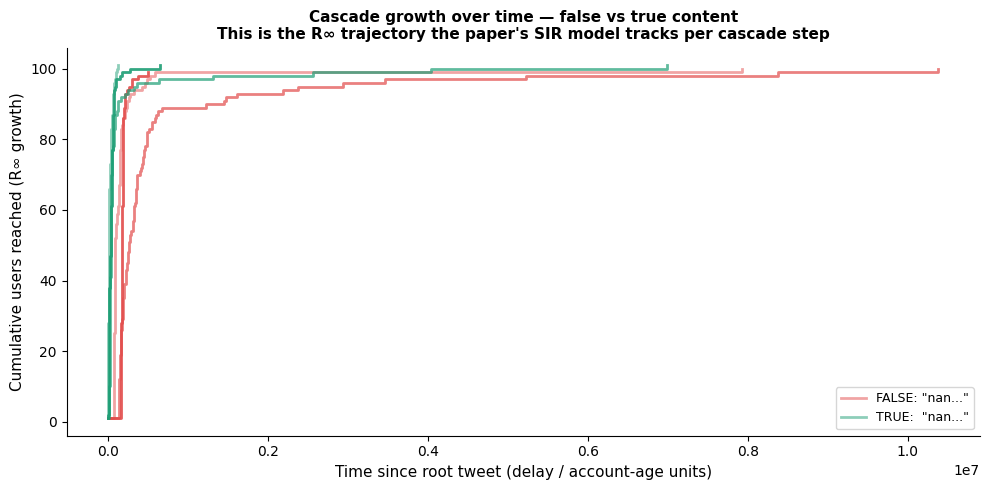

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/cascade_timelines.png


In [7]:
# ── Cascade timelines: cumulative R-infinity growth curve ────────────────
# x-axis = time since root; y-axis = cumulative users reached.
# This is exactly the R_inf growth the paper's SIR model tracks.
# FIX: get_timestamps now checks both 'delay' (Twitter) and 'time' (WICO).
timeline_false = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'false'][:3]
timeline_true  = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'true'][:3]

fig, ax = plt.subplots(figsize=(10, 5))

def get_timestamps(G):
    """Extract sorted timestamps from node attributes (delay or time)."""
    ts = []
    for _, data in G.nodes(data=True):
        for attr in ('delay', 'time'):
            t = data.get(attr)
            try:
                ts.append(float(t))
                break
            except (TypeError, ValueError):
                pass
    return sorted(ts)

has_timeline = False
for i, (row, G, _) in enumerate(timeline_false):
    times = get_timestamps(G)
    if len(times) < 2:
        continue
    has_timeline = True
    short = str(row.get('text',''))[:30]
    ax.step(times, list(range(1, len(times) + 1)), where='post',
            color='#E24B4A', alpha=0.5 + 0.2 * i, linewidth=2,
            label=f'FALSE: "{short}..."' if i == 0 else '_nolegend_')

for i, (row, G, _) in enumerate(timeline_true):
    times = get_timestamps(G)
    if len(times) < 2:
        continue
    has_timeline = True
    short = str(row.get('text',''))[:30]
    ax.step(times, list(range(1, len(times) + 1)), where='post',
            color='#1D9E75', alpha=0.5 + 0.2 * i, linewidth=2,
            label=f'TRUE:  "{short}..."' if i == 0 else '_nolegend_')

if has_timeline:
    ax.set_xlabel('Time since root tweet (delay / account-age units)', fontsize=11)
    ax.set_ylabel('Cumulative users reached (R\u221e growth)', fontsize=11)
    ax.set_title(
        'Cascade growth over time \u2014 false vs true content\n'
        'This is the R\u221e trajectory the paper\'s SIR model tracks per cascade step',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    out = FIG_DIR / 'cascade_timelines.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
else:
    print('No timestamp data found in these trees \u2014 timeline plot skipped.')
    print('Twitter15/16 trees store delay in node attrs; WICO stores time in nodes.csv.')


## 5c. BiGCN dual view — top-down vs bottom-up (WICO)

BiGCN processes each propagation graph in TWO directions simultaneously:
- **Top-down** (root → leaves): captures how fast the rumor fans out
- **Bottom-up** (leaves → root): captures how the community response aggregates

This dual view is applied here to the largest **WICO false** cascade.
False/conspiracy content typically shows a wide, shallow top-down fan (burst spreading)
while true content shows a deeper bottom-up chain (verification propagating back).
This asymmetry is exactly what the GCN learns to detect.

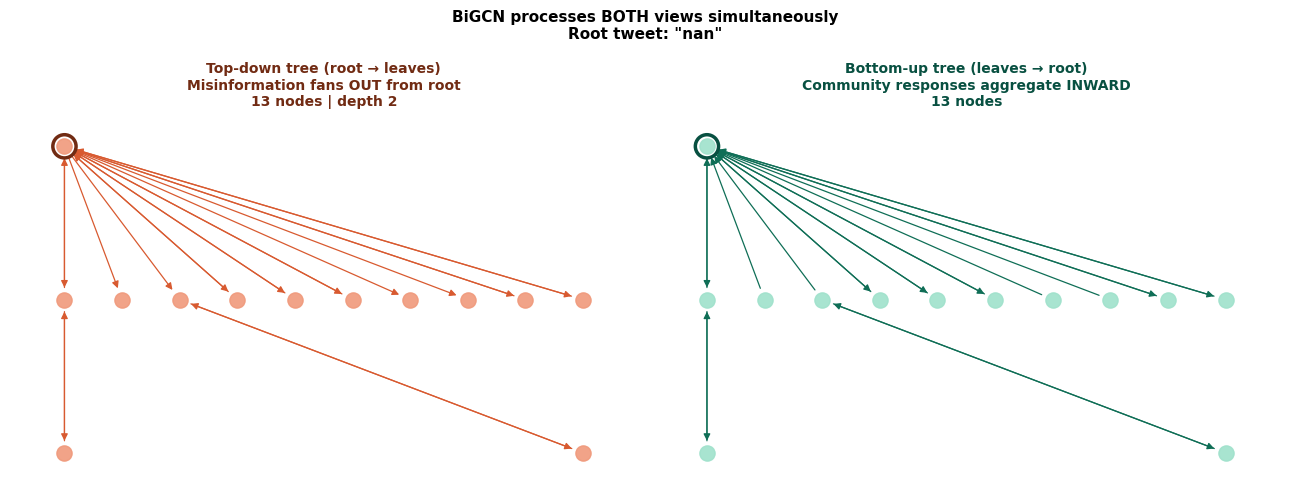

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/bigcn_dual_view.png

Top-down  → fed to the TD-GCN branch of BiGCN
Bottom-up → fed to the BU-GCN branch of BiGCN
Both embeddings are concatenated before the final classifier.


In [8]:
# BiGCN dual view: top-down vs bottom-up on the largest false tree
dual_candidates = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'false']
if not dual_candidates:
    dual_candidates = visualized_graphs

if dual_candidates:
    row, G_td, rid = max(dual_candidates, key=lambda x: x[1].number_of_nodes())
    G_bu  = G_td.reverse()
    root  = find_root(G_td, rid)

    H_td, depths_td = depth_subgraph(G_td, root, max_nodes=200)
    pos = hierarchy_positions(H_td, root)
    H_bu = G_bu.subgraph(H_td.nodes()).copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('white')

    nx.draw_networkx_edges(H_td, pos, ax=ax1, edge_color='#D85A30',
                           arrows=True, arrowsize=10, width=0.9)
    nx.draw_networkx_nodes(H_td, pos, ax=ax1, node_color='#F0997B',
                           node_size=120, alpha=0.9)
    if root and root in pos:
        ax1.scatter(*pos[root], s=280, facecolors='none',
                    edgecolors='#712B13', linewidths=2.5, zorder=5)
    ax1.set_title(
        'Top-down tree (root \u2192 leaves)\n'
        'Misinformation fans OUT from root\n'
        f'{H_td.number_of_nodes()} nodes | '
        f'depth {max(depths_td.values()) if depths_td else 0}',
        fontsize=10, fontweight='bold', color='#712B13'
    )
    ax1.axis('off')

    nx.draw_networkx_edges(H_bu, pos, ax=ax2, edge_color='#0F6E56',
                           arrows=True, arrowsize=10, width=0.9)
    nx.draw_networkx_nodes(H_bu, pos, ax=ax2, node_color='#9FE1CB',
                           node_size=120, alpha=0.9)
    if root and root in pos:
        ax2.scatter(*pos[root], s=280, facecolors='none',
                    edgecolors='#085041', linewidths=2.5, zorder=5)
    ax2.set_title(
        'Bottom-up tree (leaves \u2192 root)\n'
        'Community responses aggregate INWARD\n'
        f'{H_bu.number_of_nodes()} nodes',
        fontsize=10, fontweight='bold', color='#085041'
    )
    ax2.axis('off')

    short_text = str(row.get('text', ''))[:70]
    plt.suptitle(
        f'BiGCN processes BOTH views simultaneously\n'
        f'Root tweet: "{short_text}"',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    out = FIG_DIR / 'bigcn_dual_view.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
    print()
    print('Top-down  \u2192 fed to the TD-GCN branch of BiGCN')
    print('Bottom-up \u2192 fed to the BU-GCN branch of BiGCN')
    print('Both embeddings are concatenated before the final classifier.')
else:
    print('No graphs loaded \u2014 run visualization section first.')


## 6. Aggregate WICO true vs false comparisons

These are exploratory plots for Phase 1 using **WICO data only**.
They are not model results, but verify whether WICO contains structural
differences that later notebooks can exploit.
Twitter15/16 comparisons are in Section 7 below.

WICO cascades available: 2502 ({'true': 1905, 'false': 597})


/tmp/ipykernel_84300/3438759792.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true (non-conspiracy)', 'false (conspiracy)'])


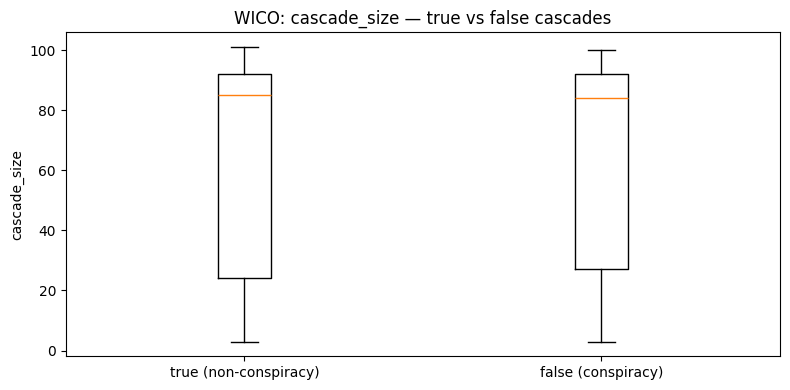

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/wico_aggregate_cascade_size_true_vs_false.png


/tmp/ipykernel_84300/3438759792.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true (non-conspiracy)', 'false (conspiracy)'])


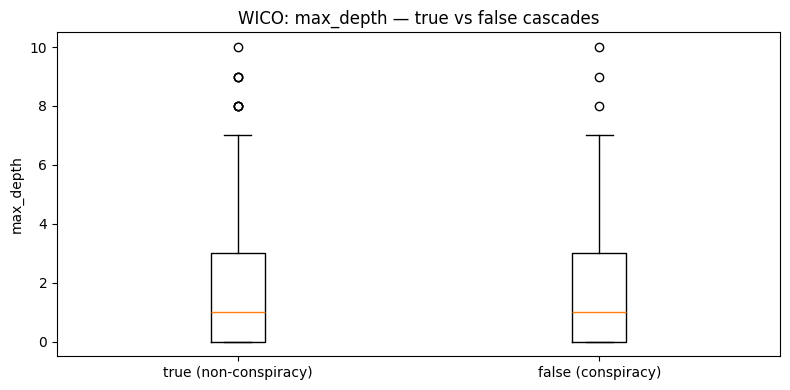

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/wico_aggregate_max_depth_true_vs_false.png


/tmp/ipykernel_84300/3438759792.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true (non-conspiracy)', 'false (conspiracy)'])


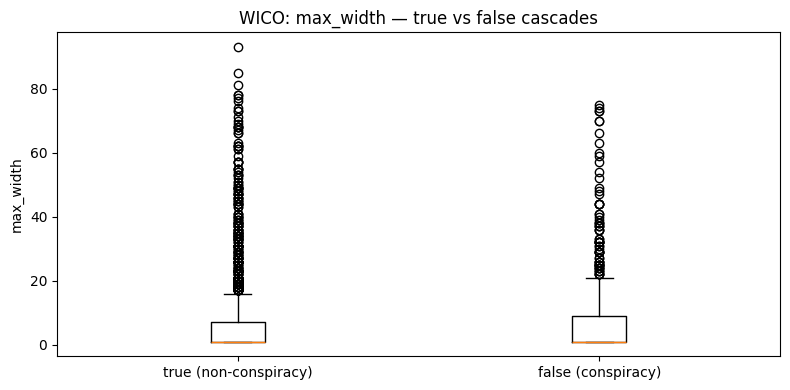

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/wico_aggregate_max_width_true_vs_false.png


/tmp/ipykernel_84300/3438759792.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true (non-conspiracy)', 'false (conspiracy)'])


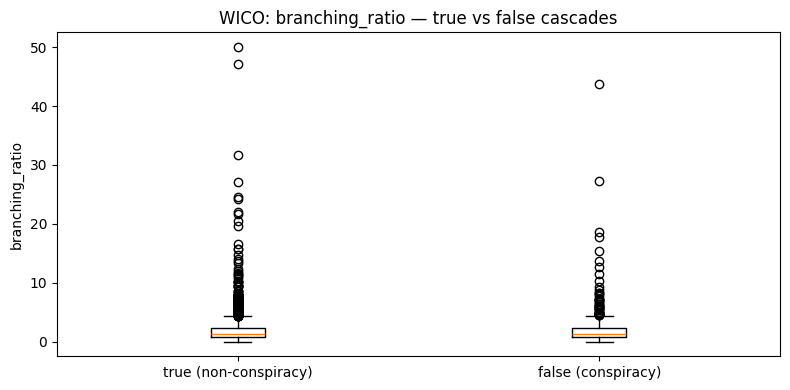

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/wico_aggregate_branching_ratio_true_vs_false.png


In [9]:
# Aggregate comparisons — WICO only
wico_plot_df = tree_summary[
    tree_summary['dataset'].eq('WICO') &
    tree_summary['label'].isin(['true','false'])
].copy()

if wico_plot_df.empty:
    print('No WICO true/false data available for aggregate comparison.')
    print('Check that explore_data.ipynb ran with WICO Graph data present.')
else:
    print(f'WICO cascades available: {len(wico_plot_df)} ({wico_plot_df["label"].value_counts().to_dict()})')
    for metric in ['cascade_size', 'max_depth', 'max_width', 'branching_ratio']:
        plt.figure(figsize=(8, 4))
        data   = [wico_plot_df.loc[wico_plot_df['label'].eq(label), metric].dropna().values
                  for label in ['true', 'false']]
        plt.boxplot(data, labels=['true (non-conspiracy)', 'false (conspiracy)'])
        plt.ylabel(metric)
        plt.title(f'WICO: {metric} — true vs false cascades')
        plt.tight_layout()
        out = FIG_DIR / f'wico_aggregate_{metric}_true_vs_false.png'
        plt.savefig(out, dpi=180)
        plt.show()
        print('Saved:', out)


## 7. Twitter15/16 visualizations (reference, separate from WICO)

This section performs the same tree visualizations on **Twitter15 and Twitter16** data.
It is completely separate from the WICO analysis above.
Run this section to compare Twitter propagation patterns with WICO patterns side by side.

No Twitter15/16 sample trees found. Generating synthetic demo trees.

Twitter cascades: 6 (3 false, 3 true)


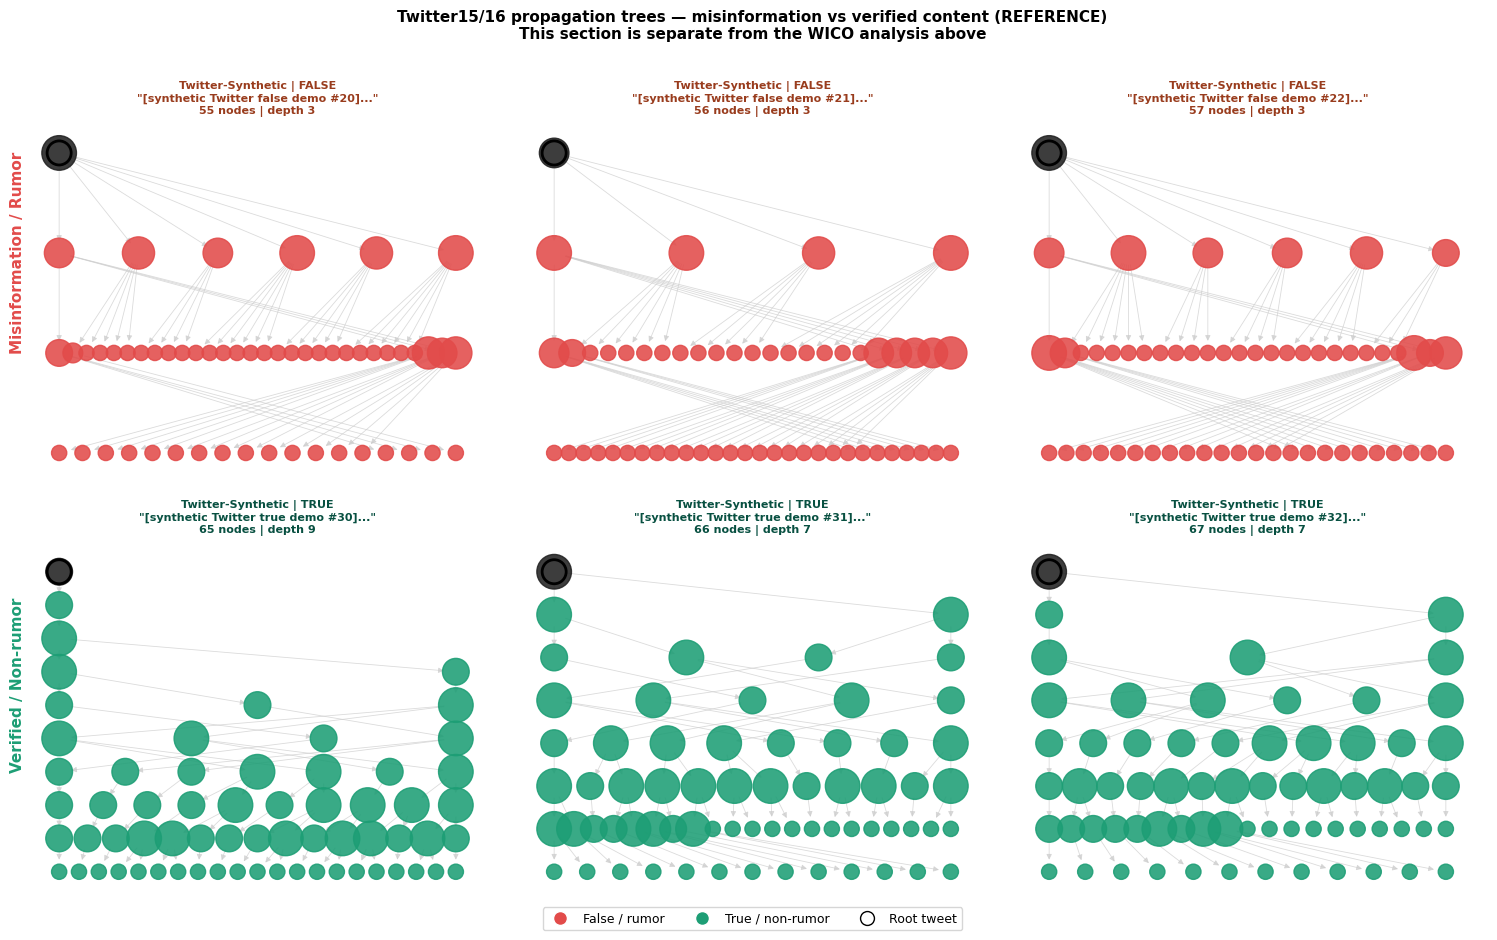

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/twitter_true_vs_false_tree_comparison.png


/tmp/ipykernel_84300/2231399786.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true', 'false'])


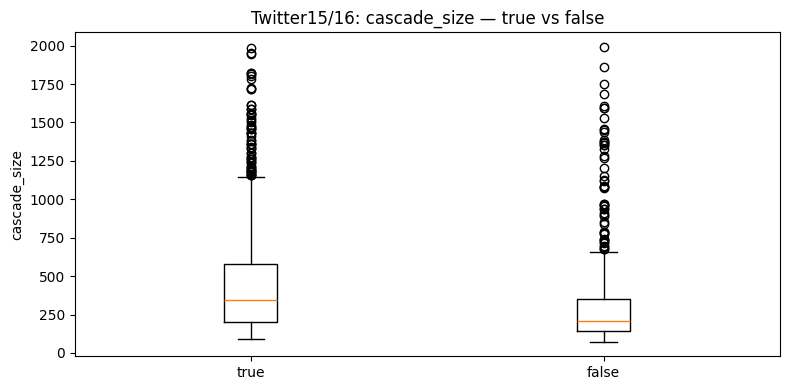

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/twitter_aggregate_cascade_size.png


/tmp/ipykernel_84300/2231399786.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true', 'false'])


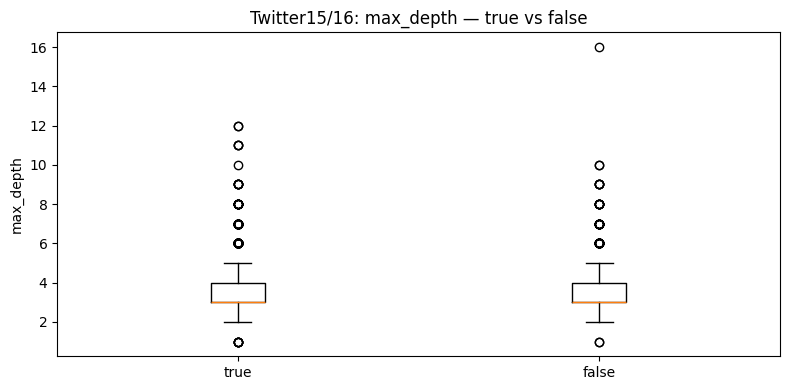

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/twitter_aggregate_max_depth.png


/tmp/ipykernel_84300/2231399786.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true', 'false'])


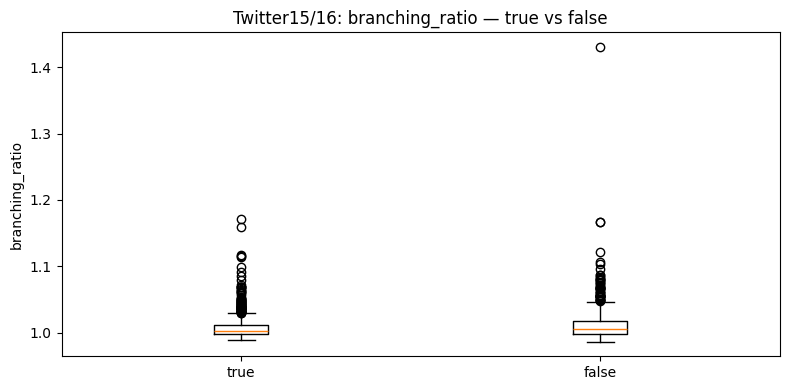

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/twitter_aggregate_branching_ratio.png


In [10]:
# ── Twitter15/16 visualizations — reference only, separate from WICO ─────

twitter_sample = (sample_trees[sample_trees['dataset'].isin(['Twitter15','Twitter16'])]
                  if not sample_trees.empty else pd.DataFrame())

twitter_loaded = []

if (not twitter_sample.empty
        and 'graph_path' in twitter_sample.columns
        and twitter_sample['graph_path'].notna().any()):
    print('Loading Twitter15/16 examples...')
    for target_label in ['false', 'true']:
        candidates = twitter_sample[
            twitter_sample['label'].eq(target_label) &
            twitter_sample['graph_path'].notna()
        ].sort_values('cascade_size', ascending=False)
        count = 0
        for _, row in candidates.iterrows():
            if count >= 3:
                break
            try:
                G, root_user_id = load_graph_for_row(row)
                twitter_loaded.append((row.to_dict(), G, root_user_id))
                count += 1
            except Exception as e:
                print(f'  Skipped {row.get("tweet_id")}: {e}')
else:
    print('No Twitter15/16 sample trees found. Generating synthetic demo trees.')
    for label, seeds in [('false', [20, 21, 22]), ('true', [30, 31, 32])]:
        for seed in seeds:
            G, root_user_id = make_synthetic_tree(label, n_nodes=35 + seed, seed=seed)
            row = {
                'dataset': 'Twitter-Synthetic', 'tweet_id': f'tw_demo_{label}_{seed}',
                'content_id': f'tw_demo_{label}_{seed}', 'label': label,
                'text': f'[synthetic Twitter {label} demo #{seed}]',
                'graph_path': None, 'root_user': root_user_id,
                'cascade_size': G.number_of_nodes(),
            }
            twitter_loaded.append((row, G, root_user_id))

if twitter_loaded:
    n_false_tw = sum(1 for r, _, _ in twitter_loaded if r['label'] == 'false')
    n_true_tw  = sum(1 for r, _, _ in twitter_loaded if r['label'] == 'true')
    print(f'\nTwitter cascades: {len(twitter_loaded)} ({n_false_tw} false, {n_true_tw} true)')

    # Side-by-side grid
    tw_false = [(r, G, rid) for r, G, rid in twitter_loaded if r['label'] == 'false'][:3]
    tw_true  = [(r, G, rid) for r, G, rid in twitter_loaded if r['label'] == 'true'][:3]
    n_cols_tw = max(len(tw_false), len(tw_true), 1)

    fig, axes = plt.subplots(2, n_cols_tw, figsize=(5 * n_cols_tw, 9), squeeze=False)
    COLOR = {'false': '#E24B4A', 'true': '#1D9E75'}
    ROW_LABEL = {'false': 'Misinformation / Rumor', 'true': 'Verified / Non-rumor'}

    for row_idx, (label, items) in enumerate([('false', tw_false), ('true', tw_true)]):
        for col_idx in range(n_cols_tw):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(items):
                ax.set_visible(False)
                continue
            row, G, rid = items[col_idx]
            root = find_root(G, rid)
            H, depths, pos = draw_tree_on_ax(ax, G, root=root,
                                             color=COLOR[label], max_nodes=250)
            short = str(row.get('text', ''))[:50]
            ax.set_title(
                f'{row.get("dataset","Twitter")} | {label.upper()}\n\"{short}...\"\n'
                f'{H.number_of_nodes()} nodes | depth {max(depths.values()) if depths else 0}',
                fontsize=8, fontweight='bold',
                color='#993C1D' if label == 'false' else '#085041'
            )
        fig.text(0.005, 0.74 if label == 'false' else 0.26,
                 ROW_LABEL[label], fontsize=11, fontweight='bold',
                 color=COLOR[label], rotation=90, va='center')

    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=10, label='False / rumor'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D9E75', markersize=10, label='True / non-rumor'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=10, label='Root tweet'),
    ], loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(
        'Twitter15/16 propagation trees — misinformation vs verified content (REFERENCE)\n'
        'This section is separate from the WICO analysis above',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    out = FIG_DIR / 'twitter_true_vs_false_tree_comparison.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)

    # Aggregate boxplots for Twitter
    twitter_plot_df = tree_summary[
        tree_summary['dataset'].isin(['Twitter15','Twitter16']) &
        tree_summary['label'].isin(['true','false'])
    ].copy()
    if not twitter_plot_df.empty:
        for metric in ['cascade_size', 'max_depth', 'branching_ratio']:
            plt.figure(figsize=(8, 4))
            data = [twitter_plot_df.loc[twitter_plot_df['label'].eq(label), metric].dropna().values
                    for label in ['true', 'false']]
            plt.boxplot(data, labels=['true', 'false'])
            plt.ylabel(metric)
            plt.title(f'Twitter15/16: {metric} — true vs false')
            plt.tight_layout()
            out_metric = FIG_DIR / f'twitter_aggregate_{metric}.png'
            plt.savefig(out_metric, dpi=180)
            plt.show()
            print('Saved:', out_metric)
else:
    print('No Twitter trees loaded.')


## 8. Phase 1 outputs

Generated files:

**WICO (primary analysis):**
- `evaluation/propagation_tree_summary.csv` — per-cascade stats including all datasets
- `evaluation/sample_tree_ids.csv` — selected example cascades (WICO-prioritised)
- `evaluation/phase1_summary_charts.png` — WICO label distribution + branching ratio + cascade size
- `evaluation/tree_figures/wico_true_vs_false_graph_comparison.png` — WICO 3×2 graph grid
- `evaluation/tree_figures/wico_aggregate_*.png` — WICO per-metric boxplots
- `evaluation/tree_figures/cascade_timelines.png` — R∞ growth curves (WICO)
- `evaluation/tree_figures/bigcn_dual_view.png` — top-down vs bottom-up (WICO)

**Twitter15/16 (reference, separate):**
- `evaluation/tree_figures/twitter_true_vs_false_tree_comparison.png` — Twitter 3×2 tree grid
- `evaluation/tree_figures/twitter_aggregate_*.png` — Twitter per-metric boxplots

**What Phase 2 consumes from here:**
- `propagation_tree_summary.csv` → feature engineering baselines
- The `graph_path` column → PyG graph conversion in `gnn/dataset.py`
- `branching_ratio` distributions from WICO → validate LP optimizer α feasibility